In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
import pandas as pd
import numpy as np

In [4]:
df=pd.read_csv('Live.csv')
df.head()

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


In [5]:
df.isna().sum()

status_id              0
status_type            0
status_published       0
num_reactions          0
num_comments           0
num_shares             0
num_likes              0
num_loves              0
num_wows               0
num_hahas              0
num_sads               0
num_angrys             0
Column1             7050
Column2             7050
Column3             7050
Column4             7050
dtype: int64

In [6]:
# applying kmeans 
df.drop(columns=['Column1','Column2','Column3','Column4'] , axis=1)

,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
0,246675545449582_1649696485147474,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0
1,246675545449582_1649426988507757,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0
2,246675545449582_1648730588577397,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0
3,246675545449582_1648576705259452,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0
4,246675545449582_1645700502213739,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...
7045,1050855161656896_1061863470556065,photo,9/24/2016 2:58,89,0,0,89,0,0,0,0,0
7046,1050855161656896_1061334757275603,photo,9/23/2016 11:19,16,0,0,14,1,0,1,0,0
7047,1050855161656896_1060126464063099,photo,9/21/2016 23:03,2,0,0,1,1,0,0,0,0
7048,1050855161656896_1058663487542730,photo,9/20/2016 0:43,351,12,22,349,2,0,0,0,0


In [7]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [14]:
from sklearn.decomposition import PCA

In [9]:
engagement_features = ['num_reactions', 'num_comments', 'num_shares', 
                      'num_likes', 'num_loves', 'num_wows', 'num_hahas', 
                      'num_sads', 'num_angrys']

X = df[engagement_features].copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

wcss = []  # within-cluster sum of squares
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

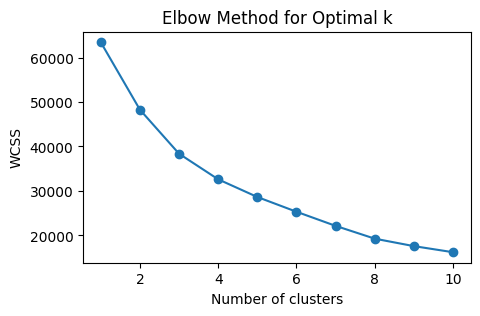

In [12]:
plt.figure(figsize=(5, 3))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

In [13]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = clusters

# Analyze cluster characteristics
cluster_summary = df.groupby('cluster')[engagement_features].mean()
print("Cluster Summary:")
print(cluster_summary)

Cluster Summary:
         num_reactions  num_comments  num_shares    num_likes   num_loves  \
cluster                                                                     
0           109.824976     74.464548   16.564037   102.863302    6.005110   
1          1823.311828     61.333333   11.645161  1817.534946    3.104839   
2           545.732240   2808.262295  405.508197   422.497268  111.010929   
3           403.294118    488.529412   51.588235   333.294118   37.058824   
4          1507.151515   1711.151515  751.818182  1075.787879  294.484848   

           num_wows  num_hahas   num_sads  num_angrys  
cluster                                                
0          0.523315   0.287608   0.105717    0.037847  
1          2.435484   0.198925   0.032258    0.005376  
2          3.830601   5.562842   1.502732    1.311475  
3          4.823529   1.647059  25.294118    1.176471  
4        103.727273  29.424242   1.939394    1.787879  


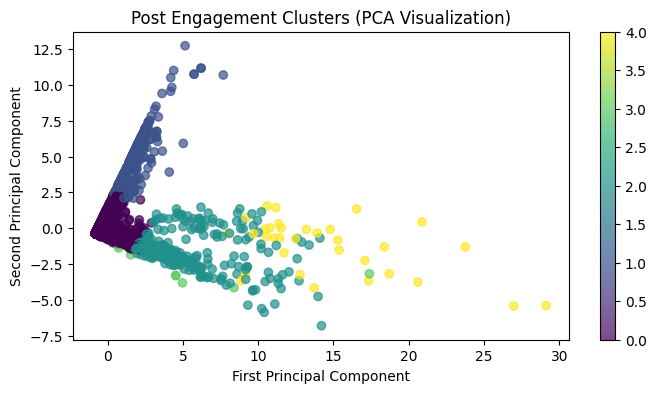

In [29]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 4))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.7)
plt.colorbar(scatter)
plt.title('Post Engagement Clusters (PCA Visualization)')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.show()

In [17]:
print("\nCluster Interpretation:")
for cluster_id in range(5):
    cluster_data = df[df['cluster'] == cluster_id]
    print(f"\nCluster {cluster_id} (n={len(cluster_data)}):")
    print(f"  Avg reactions: {cluster_data['num_reactions'].mean():.1f}")
    print(f"  Avg comments: {cluster_data['num_comments'].mean():.1f}")
    print(f"  Avg shares: {cluster_data['num_shares'].mean():.1f}")
    print(f"  Most common status type: {cluster_data['status_type'].mode().iloc[0]}")


Cluster Interpretation:

Cluster 0 (n=6262):
  Avg reactions: 109.8
  Avg comments: 74.5
  Avg shares: 16.6
  Most common status type: photo

Cluster 1 (n=372):
  Avg reactions: 1823.3
  Avg comments: 61.3
  Avg shares: 11.6
  Most common status type: photo

Cluster 2 (n=366):
  Avg reactions: 545.7
  Avg comments: 2808.3
  Avg shares: 405.5
  Most common status type: video

Cluster 3 (n=17):
  Avg reactions: 403.3
  Avg comments: 488.5
  Avg shares: 51.6
  Most common status type: photo

Cluster 4 (n=33):
  Avg reactions: 1507.2
  Avg comments: 1711.2
  Avg shares: 751.8
  Most common status type: video


In [27]:
from sklearn.metrics import silhouette_score

In [30]:
silhouette_coefficient = []  # if most of the value is positive , then it does lie in that cluster
for k in range(2,11):
  kmeans = KMeans(n_clusters=k , init='k-means++')
  kmeans.fit(X_scaled)
  score = silhouette_score(X_scaled,kmeans.labels_)
  silhouette_coefficient.append(score)

Text(0, 0.5, 'silhouette coefficient')

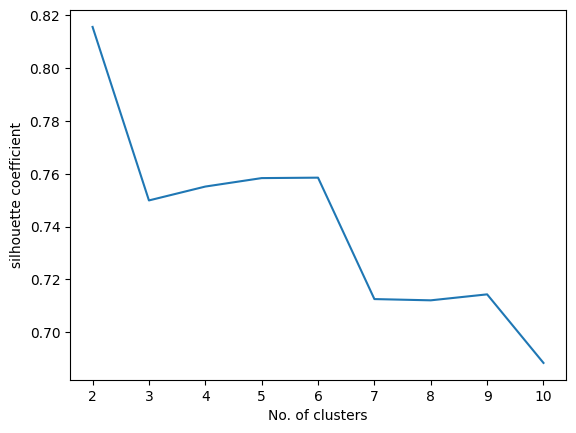

In [31]:
plt.plot(range(2,11),silhouette_coefficient)
plt.xticks(range(2,11))
plt.xlabel("No. of clusters")
plt.ylabel("silhouette coefficient")
  
    
    
 